Hiperelasztikus modellek számításai

In [113]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import random as rnd


---

In [114]:
def Sigma_NH_UAX(lam,C10):
    return 2*C10*(lam**2-lam**-1)
def Sigma_NH_BIAX(lam,C10):
    return 2*C10*(lam**2-lam**-4)
def Sigma_NH_PLANAR(lam,C10):
    sigma_1 = 2*C10*(lam**2-lam**-2)
    sigma_2 = 2*C10*(1-lam**-2)
    return [sigma_1,sigma_2]

def P_NH_UAX(lam,C10):
    return (2*C10*(lam**2-lam**-1))*lam**-1
def P_NH_BIAX(lam,C10):
    return (2*C10*(lam**2-lam**-4))*lam-1
def P_NH_PLANAR(lam,C10):
    sigma_1 = (2*C10*(lam**2-lam**-2))*lam-1
    sigma_2 = 2*C10*(1-lam**-2)
    return [sigma_1,sigma_2]

def Sigma_MR_UAX(lam,C10,C01):
    return 2*C10*(lam**2-lam**-1)+2*C01*(lam-lam**-2)
def Sigma_MR_BIAX(lam,C10,C01):
    return 2*C10*(lam**2-lam**-4)+2*C01*(lam**4-lam**-2)
def Sigma_MR_PLANAR(lam,C10,C01):
    sigma_1 = 2*C10*(lam**2-lam**-2)+2*C01*(lam**2-lam**-2)
    sigma_2 = 2*C10*(1-lam**-2)+2*C01*(lam**2-1)
    return [sigma_1,sigma_2]

def P_MR_UAX(lam,C10,C01):
    return (2*C10*(lam**2-lam**-1)+2*C01*(lam-lam**-2))*lam**-1
def P_MR_BIAX(lam,C10,C01):
    return (2*C10*(lam**2-lam**-4)+2*C01*(lam**4-lam**-2))*lam**-1
def P_MR_PLANAR(lam,C10,C01):
    sigma_1 = (2*C10*(lam**2-lam**-2)+2*C01*(lam**2-lam**-2))*lam**-1
    sigma_2 = 2*C10*(1-lam**-2)+2*C01*(lam**2-1)
    return [sigma_1,sigma_2]

def Sigma_Ogden_UAX(lam,mu,alpha,N):
    sigma_1 = 0
    for i in range(N):
        sigma_1 += 2*mu[i]/alpha[i]*(lam**alpha[i]-lam**(-alpha[i]/2))
    return sigma_1

def Sigma_Ogden_UAX_N3(lam,mu1,alpha1,mu2,alpha2,mu3,alpha3):
    sigma_1 = (2*mu1/alpha1*(lam**alpha1-lam**(-alpha1/2))
    +2*mu2/alpha2*(lam**alpha2-lam**(-alpha2/2))+2*mu3/alpha3*(lam**alpha3-lam**(-alpha3/2)))
    return sigma_1
    
def Sigma_Ogden_BIAX(lam,mu,alpha,N):
    sigma_1 = 0
    for i in range(N):
        sigma_1 += 2*mu[i]/alpha[i]*(lam**alpha[i]-lam**(-2*alpha[i]))
    return sigma_1
def Sigma_Ogden_PLANAR(lam,mu,alpha,N):
    sigma_1 = 0
    sigma_2 = 0
    for i in range(N):
        sigma_1+= 2*mu[i]/alpha[i]*(lam**alpha[i]-lam**(-alpha[i]))
        sigma_2+= 2*mu[i]/alpha[i]*(1-lam**(-alpha[i]))
    return [sigma_1,sigma_2]

def P_Ogden_UAX(lam,mu,alpha,N):
    sigma_1 = 0
    for i in range(N):
        sigma_1 += (2*mu[i]/alpha[i]*(lam**alpha[i]-lam**(-alpha[i]/2)))*lam**-1
    return sigma_1
def P_Ogden_BIAX(lam,mu,alpha,N):
    sigma_1 = 0
    for i in range(N):
        sigma_1 += (2*mu[i]/alpha[i]*(lam**alpha[i]-lam**(-2*alpha[i])))*lam**-1
    return sigma_1
def P_Ogden_PLANAR(lam,mu,alpha,N):
    sigma_1 = 0
    sigma_2 = 0
    for i in range(N):
        sigma_1+= (2*mu[i]/alpha[i]*(lam**alpha[i]-lam**(-alpha[i])))*lam**-1
        sigma_2+= 2*mu[i]/alpha[i]*(1-lam**(-alpha[i]))
    return [sigma_1,sigma_2]

---

In [115]:
lam = 1.4
C10 = 10
C01 = 5
mu = [10,5]
alpha = [2,3]
N=2

---

In [116]:
'''
print(f"Sigma NEO-HOOKE modellel UNIAX esetben: {Sigma_NH_UAX(lam,C10):.2f}")
print(f"Sigma NEO-HOOKE modellel BIAX esetben: {Sigma_NH_BIAX(lam,C10):.2f}")
print(f"Sigma1 NEO-HOOKE modellel PLANAR esetben: {Sigma_NH_PLANAR(lam,C10)[0]:.2f}")
print(f"Sigma2 NEO-HOOKE modellel PLANAR esetben: {Sigma_NH_PLANAR(lam,C10)[1]:.2f}")
print("---")
print(f"P NEO-HOOKE modellel UNIAX esetben: {P_NH_UAX(lam,C10):.2f}")
print(f"P NEO-HOOKE modellel BIAX esetben: {P_NH_BIAX(lam,C10):.2f}")
print(f"P1 NEO-HOOKE modellel PLANAR esetben: {P_NH_PLANAR(lam,C10)[0]:.2f}")
print(f"P2 NEO-HOOKE modellel PLANAR esetben: {P_NH_PLANAR(lam,C10)[1]:.2f}")
print("---")
print(f"Sigma MOONEY-RIVLIN modellel UNIAX esetben: {Sigma_MR_UAX(lam,C10,C01):.2f}")
print(f"Sigma MOONEY-RIVLIN modellel BIAX esetben: {Sigma_MR_BIAX(lam,C10,C01):.2f}")
print(f"Sigma1 MOONEY-RIVLIN modellel PLANAR esetben: {Sigma_MR_PLANAR(lam,C10,C01)[0]:.2f}")
print(f"Sigma2 MOONEY-RIVLIN modellel PLANAR esetben: {Sigma_MR_PLANAR(lam,C10,C01)[1]:.2f}")
print("---")
print(f"P MOONEY-RIVLIN modellel UNIAX esetben: {P_MR_UAX(lam,C10,C01):.2f}")
print(f"P MOONEY-RIVLIN modellel BIAX esetben: {P_MR_BIAX(lam,C10,C01):.2f}")
print(f"P1 MOONEY-RIVLIN modellel PLANAR esetben: {P_MR_PLANAR(lam,C10,C01)[0]:.2f}")
print(f"P2 MOONEY-RIVLIN modellel PLANAR esetben: {P_MR_PLANAR(lam,C10,C01)[1]:.2f}")
print("---")
print(f"Sigma OGDEN modellel UNIAX esetben: {Sigma_Ogden_UAX(lam,mu,alpha,N):.2f}")
print(f"Sigma OGDEN modellel BIAX esetben: {Sigma_Ogden_BIAX(lam,mu,alpha,N):.2f}")
print(f"Sigma1 OGDEN modellel PLANAR esetben: {Sigma_Ogden_PLANAR(lam,mu,alpha,N)[0]:.2f}")
print(f"Sigma2 OGDEN modellel PLANAR esetben: {Sigma_Ogden_PLANAR(lam,mu,alpha,N)[1]:.2f}")
print("---")
print(f"P OGDEN modellel UNIAX esetben: {P_Ogden_UAX(lam,mu,alpha,N):.2f}")
print(f"P OGDEN modellel BIAX esetben: {P_Ogden_BIAX(lam,mu,alpha,N):.2f}")
print(f"P1 OGDEN modellel PLANAR esetben: {P_Ogden_PLANAR(lam,mu,alpha,N)[0]:.2f}")
print(f"P2 OGDEN modellel PLANAR esetben: {P_Ogden_PLANAR(lam,mu,alpha,N)[1]:.2f}")
'''

'\nprint(f"Sigma NEO-HOOKE modellel UNIAX esetben: {Sigma_NH_UAX(lam,C10):.2f}")\nprint(f"Sigma NEO-HOOKE modellel BIAX esetben: {Sigma_NH_BIAX(lam,C10):.2f}")\nprint(f"Sigma1 NEO-HOOKE modellel PLANAR esetben: {Sigma_NH_PLANAR(lam,C10)[0]:.2f}")\nprint(f"Sigma2 NEO-HOOKE modellel PLANAR esetben: {Sigma_NH_PLANAR(lam,C10)[1]:.2f}")\nprint("---")\nprint(f"P NEO-HOOKE modellel UNIAX esetben: {P_NH_UAX(lam,C10):.2f}")\nprint(f"P NEO-HOOKE modellel BIAX esetben: {P_NH_BIAX(lam,C10):.2f}")\nprint(f"P1 NEO-HOOKE modellel PLANAR esetben: {P_NH_PLANAR(lam,C10)[0]:.2f}")\nprint(f"P2 NEO-HOOKE modellel PLANAR esetben: {P_NH_PLANAR(lam,C10)[1]:.2f}")\nprint("---")\nprint(f"Sigma MOONEY-RIVLIN modellel UNIAX esetben: {Sigma_MR_UAX(lam,C10,C01):.2f}")\nprint(f"Sigma MOONEY-RIVLIN modellel BIAX esetben: {Sigma_MR_BIAX(lam,C10,C01):.2f}")\nprint(f"Sigma1 MOONEY-RIVLIN modellel PLANAR esetben: {Sigma_MR_PLANAR(lam,C10,C01)[0]:.2f}")\nprint(f"Sigma2 MOONEY-RIVLIN modellel PLANAR esetben: {Sigma_MR_PLAN

---

Illesztések, Inkompr.

NH-UAX-fit
------------
illesztett paraméterek:[9.60603176]
------------
illesztés kovarianciája:[[0.1728549]]
------------
R² = 0.9413
------------
------------
MR-UAX-fit
------------
illesztett paraméterek:[ 3.55382955 10.77621348]
------------
illesztés kovarianciája:[[  7.87562399 -13.80520427]
 [-13.80520427  24.58077652]]
------------
R² = 0.9631
------------
------------
Ogden-UAX-N3-fit
------------
illesztett paraméterek:[8.70884124 0.64188289 9.71335254 0.64199739 7.79801091 0.64197678]
------------
illesztés kovarianciája:[[ 1.28252934e+16  8.06346028e+12 -7.36844942e+15 -2.70481697e+14
  -5.45684426e+15  3.27624106e+14]
 [ 8.06346028e+12  4.71346210e+10 -5.31754906e+12 -4.44488616e+11
  -2.74590896e+12  5.00837693e+11]
 [-7.36844942e+15 -5.31754906e+12  1.74096900e+16 -3.83709604e+13
  -1.00412413e+16  5.38918208e+13]
 [-2.70481697e+14 -4.44488616e+11 -3.83709604e+13  1.46963547e+13
   3.08852674e+14 -1.78034594e+13]
 [-5.45684426e+15 -2.74590896e+12 -1.00412413e+16  3.088

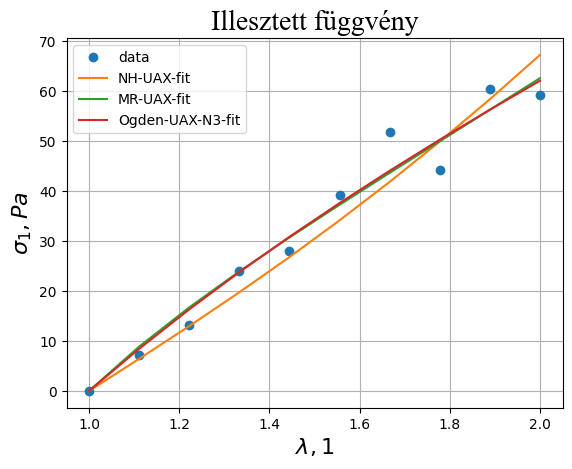

In [117]:
lam_values = np.linspace(1,2,10)

def NH_UAX_Data_values(C10,lam_max,N):
    lam = np.linspace(1,lam_max,N)
    sigma_values = np.zeros(N)
    for i in range(len(sigma_values)):
        sigma_values[i] = 2*C10*(lam[i]**2-lam[i]**-1)*rnd.uniform(0.8,1.2)
    return sigma_values
#sigma1_vals = [5,6,6.5,6.8,7.1,8.4,8.6,8.7,8.88,9.0]
sigma1_values = NH_UAX_Data_values(10,2,10)
fig,ax1 = plt.subplots()

ax1.grid()
ax1.set_ybound(0,2)
ax1.plot(lam_values, sigma1_values, 'o', label='data')
ax1.set_title("Illesztett függvény", fontsize=20, fontname="Times New Roman")
ax1.set_xlabel(r"$\lambda, 1$", fontsize=16, fontname="Times New Roman")
ax1.set_ylabel(r"$\sigma_1, Pa$", fontsize=16, fontname="Times New Roman")

def curve_fitting_incompr(function,lam_vals,sigma1_vals,funcname,axis):

    parameters, covariance = curve_fit(function,lam_vals,sigma1_vals, maxfev=10000)
    print(funcname)
    print("------------")
    print(f"illesztett paraméterek:{parameters}")
    print("------------")
    print(f"illesztés kovarianciája:{covariance}")
    print("------------")
    match(funcname):
        case "NH-UAX-fit":
            fitted_function = Sigma_NH_UAX(lam_vals, parameters[0])
        case "MR-UAX-fit":
            fitted_function = Sigma_MR_UAX(lam_vals, parameters[0],parameters[1])
        case "Ogden-UAX-N3-fit":
            fitted_function = Sigma_Ogden_UAX_N3(lam_vals, parameters[0],parameters[1],parameters[2],
                                                 parameters[3],parameters[4],parameters[5])

    axis.plot(lam_vals, fitted_function, '-', label=funcname)
    ax1.legend()
    


    # Residuals
    residuals = sigma1_vals - fitted_function

    # Sum of squared residuals
    ss_res = np.sum(residuals**2)

    # Total sum of squares
    ss_tot = np.sum((sigma1_vals - np.mean(sigma1_vals))**2)

    # R²
    r2 = 1 - ss_res / ss_tot

    print(f"R² = {r2:.4f}")
    print("------------")
    print("------------")

curve_fitting_incompr(Sigma_NH_UAX,lam_values,sigma1_values,"NH-UAX-fit",ax1)
curve_fitting_incompr(Sigma_MR_UAX,lam_values,sigma1_values,"MR-UAX-fit",ax1)
curve_fitting_incompr(Sigma_Ogden_UAX_N3,lam_values,sigma1_values,"Ogden-UAX-N3-fit",ax1)



